In [24]:
import numpy as np
import h5py
import pandas as pd
with h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r') as hdf:
    size = np.zeros(shape=(20000000, len(hdf.keys())))
    data = pd.DataFrame(size, columns=hdf.keys(), dtype=np.float32)
    for key in hdf.keys(): data[key] = hdf[key]
data

,chi1x,chi1y,chi1z,chi2x,chi2y,chi2z,dec,det,iota,mtot,psi,q,ra,snr,z
0,-0.307201,0.276165,-0.430760,-0.161114,-0.092334,-0.414647,-0.329671,0,1.809310,906.803562,1.286031,0.624780,-3.116784,0.822509,2.139659
1,-0.734712,-0.498493,-0.298162,0.057532,-0.844992,0.014708,0.526740,0,0.820820,59.102112,0.934308,0.986650,1.360291,1.093237,2.438707
2,-0.057831,-0.703796,-0.354512,-0.215538,0.016323,0.130543,0.315799,0,2.008206,44.602750,1.535520,0.286199,0.079973,1.305398,1.869461
3,0.015260,-0.202467,-0.492768,-0.237033,-0.365363,-0.876192,0.432105,0,2.018398,534.378032,3.064086,0.538882,-1.780558,9.112974,0.428061
4,-0.016731,0.007848,0.005007,0.147519,0.231879,0.086716,-0.458711,1,2.037363,573.821705,0.752211,0.846310,2.789289,17.525534,0.772609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19999995,-0.192062,-0.132125,0.099840,0.244232,-0.610395,0.205643,0.227502,0,1.712124,47.173930,0.458902,0.721899,2.747641,0.550924,2.942686
19999996,-0.004265,-0.056190,-0.030455,0.080665,-0.263666,-0.028503,-0.289584,0,1.796748,319.515160,2.011788,0.276340,-3.010306,6.303695,1.348554
19999997,-0.558253,-0.107589,0.065246,0.305706,-0.212490,-0.412048,-0.236878,0,0.894741,536.491292,1.776291,0.909982,-1.638381,9.975289,0.826640
19999998,0.084775,-0.042762,0.017719,0.145657,0.474321,0.744677,0.104063,0,1.102068,879.055152,1.317251,0.287587,2.211932,0.920406,3.125594


In [25]:
print(np.where(np.isnan(data)))
print(np.where(np.isinf(data)))

(array([10152602], dtype=int64), array([13], dtype=int64))
(array([], dtype=int64), array([], dtype=int64))


Ok, preliminary check: let's delete these guys, since I don't like $NaN$s in my model.

In [26]:
data = data.drop(10152602, axis=0)
data = data.drop(13, axis=0)
print(np.where(np.isnan(data)))
data

(array([], dtype=int64), array([], dtype=int64))


,chi1x,chi1y,chi1z,chi2x,chi2y,chi2z,dec,det,iota,mtot,psi,q,ra,snr,z
0,-0.307201,0.276165,-0.430760,-0.161114,-0.092334,-0.414647,-0.329671,0,1.809310,906.803562,1.286031,0.624780,-3.116784,0.822509,2.139659
1,-0.734712,-0.498493,-0.298162,0.057532,-0.844992,0.014708,0.526740,0,0.820820,59.102112,0.934308,0.986650,1.360291,1.093237,2.438707
2,-0.057831,-0.703796,-0.354512,-0.215538,0.016323,0.130543,0.315799,0,2.008206,44.602750,1.535520,0.286199,0.079973,1.305398,1.869461
3,0.015260,-0.202467,-0.492768,-0.237033,-0.365363,-0.876192,0.432105,0,2.018398,534.378032,3.064086,0.538882,-1.780558,9.112974,0.428061
4,-0.016731,0.007848,0.005007,0.147519,0.231879,0.086716,-0.458711,1,2.037363,573.821705,0.752211,0.846310,2.789289,17.525534,0.772609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19999995,-0.192062,-0.132125,0.099840,0.244232,-0.610395,0.205643,0.227502,0,1.712124,47.173930,0.458902,0.721899,2.747641,0.550924,2.942686
19999996,-0.004265,-0.056190,-0.030455,0.080665,-0.263666,-0.028503,-0.289584,0,1.796748,319.515160,2.011788,0.276340,-3.010306,6.303695,1.348554
19999997,-0.558253,-0.107589,0.065246,0.305706,-0.212490,-0.412048,-0.236878,0,0.894741,536.491292,1.776291,0.909982,-1.638381,9.975289,0.826640
19999998,0.084775,-0.042762,0.017719,0.145657,0.474321,0.744677,0.104063,0,1.102068,879.055152,1.317251,0.287587,2.211932,0.920406,3.125594


All good! Let's start.

--- 

The goal here is to machine-learn the LIGO detectability: can we predict if a gravitational-wave source will be detected?

Today's task is to train a classifier (you decide which one!) and separate sources that are detectables from those that aren't.

Be creative! This is a challenge! Let's see who gets the higher completeness and/or the smaller contamination (on a validation set, of course! Careful with overfitting here!).

---

%(SNR>12) ~ 14.610 %


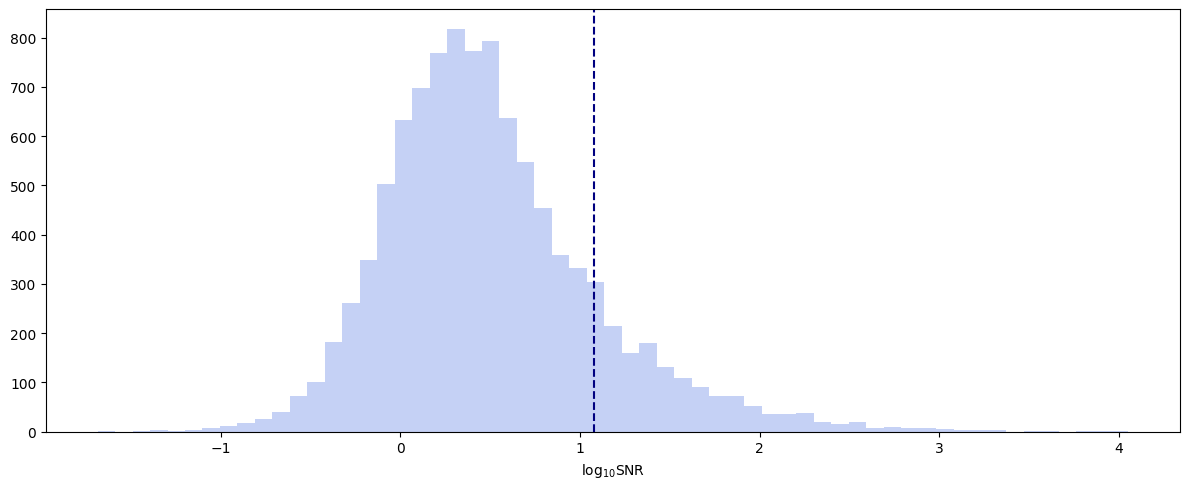

In [137]:
import matplotlib.pyplot as plt
%matplotlib inline
from astropy.visualization import hist

xsData = data.iloc[:int(1e4)]
### Let's separate the data from the labels (SNR included)
xsLabels = xsData['det']
xsSNR    = xsData['snr']
xsData   = xsData.drop('snr', axis=1)  
xsData   = xsData.drop('det', axis=1)

plt.figure(figsize=(12,5), tight_layout=True)
_ = hist(np.log10(xsSNR), bins='scott', facecolor='royalblue', alpha=0.3, density=False); 
plt.axvline(np.log10(12), c='navy', ls='--', zorder=1)
plt.xlabel(r'log$_{10}$SNR')
print(r'%(SNR>12) ~', '{0:.3f}'.format(len(xsSNR[xsSNR>12])/np.shape(xsData)[0]*100),'%')


I expect to detect roughly 14% of the original dataset to be detectable.

So... let's start with a small dataset to see whether I am able to do something. One thing that comes to my mind, but I am currently "obsessed" with PCAs, is that I could run a PCA analysis on "primary" and "secondary" features. I think, as far as GW astrophysics is concerned, that some of the parameters that come into play in our LIGO-Virgo detection are not as relevant in the final construction of the waveform, while others are extremely important.

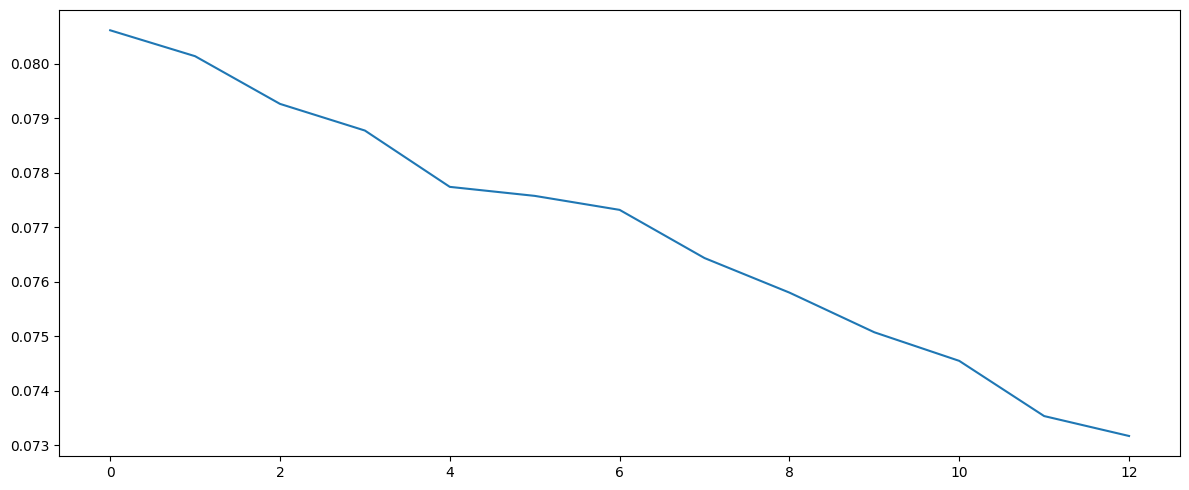

In [138]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
Pca = PCA()
Scaler = StandardScaler()
xsDataPCA = Scaler.fit_transform(xsData)
Pca.fit_transform(xsDataPCA)
plt.figure(figsize=(12,5), tight_layout=True)
plt.plot(np.arange(13), Pca.explained_variance_ratio_)

... this is not a good-looking explained variance. I would REALLY love to do some dimensionality reduction, yet it is extremely unfeasible to just "ditch" several components in this analysis, as each of them roughly explains _less_ than $10\%$ of the whole variance. Maybe I could try some non-linear dimensionality reduction?

Let's adopt a random forest classifier instead, as I personally like the how decision trees work.

True Positives : 7.05000 %
True Negatives : 85.45000 %
False Positives: 0.35000 %
False Negatives: 7.15000 %
  %   Positives: 14.20000 %
Efficiency     : 95.27027 %
Contamination  : 4.72973 %
Completeness   : 49.64789 %


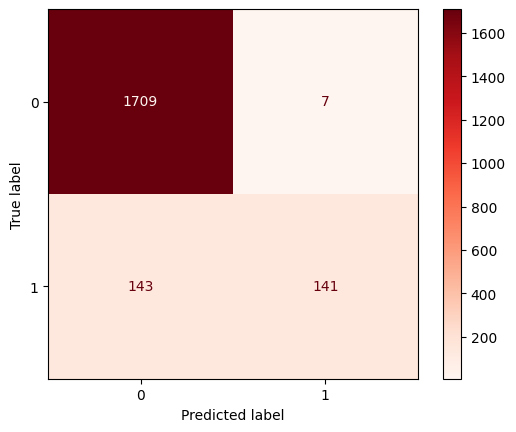

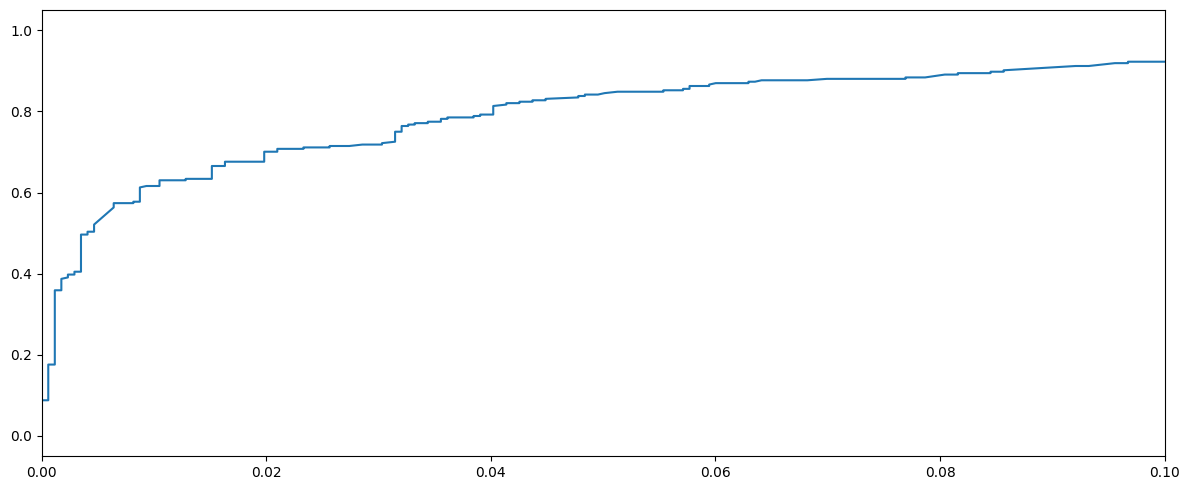

In [167]:
from sklearn.model_selection import train_test_split as TTS
Xtrain, Xtest, yTrain, yTest = TTS(xsData.to_numpy(), xsLabels.to_numpy(), test_size=0.2) #, random_state=42)
from sklearn.ensemble import RandomForestClassifier
ranfor = RandomForestClassifier(n_estimators=10, criterion='gini', n_jobs=-1,
                                max_features='sqrt', min_samples_leaf=10, max_depth=3 )
ranfor.fit(Xtrain, yTrain)
yPred = ranfor.predict(Xtest)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
CM = confusion_matrix(yTest, yPred)
N  = (CM[0,0]+CM[1,1]+CM[0,1]+CM[1,0])
TP = CM[1,1]
FP = CM[0,1]
TN = CM[0,0]
FN = CM[1,0]
print( 'True Positives : {0:.5f} %'.format(100*TP/N))
print( 'True Negatives : {0:.5f} %'.format(100*TN/N))
print( 'False Positives: {0:.5f} %'.format(100*FP/N))
print( 'False Negatives: {0:.5f} %'.format(100*FN/N))
print( '  %   Positives: {0:.5f} %'.format(100*( TP+FN )/N))
print( 'Efficiency     : {0:.5f} %'.format(100*TP/(TP+FP)))
print( 'Contamination  : {0:.5f} %'.format(100*FP/(TP+FP)))
print( 'Completeness   : {0:.5f} %'.format(100*TP/(TP+FN)))
ConfusionMatrixDisplay.from_estimator(ranfor, Xtest, yTest, cmap='Reds') #, norm=True) #(CM)

from sklearn.metrics import roc_curve
yProb = ranfor.predict_proba(Xtest)[:,1]
fpr, tpr, thresholds = roc_curve(yTest, yProb)
fig, axs = plt.subplots(1, figsize=(12,5), tight_layout=True)
plt.plot(fpr, tpr); _ = plt.xlim(0.00, 0.1)

Honestly, I think I am overfitting a little bit. Are there any features that "dominate" the decision tree? YES.

I personally noticed that the REDSHIFT is the dominant feature, when it comes to fitting the dataset: too distant (z high) $\rightarrow$ undetectable ($\rho$ low).

In [165]:
for i in range(13):
    print('{0:7} {1:.4f}%'.format(xsData.columns[i], 100*ranfor.feature_importances_[i]))

chi1x   0.0000%
chi1y   0.4816%
chi1z   1.0077%
chi2x   0.1541%
chi2y   0.3463%
chi2z   0.2220%
dec     1.4484%
iota    2.3140%
mtot    16.0122%
psi     0.4320%
q       1.4164%
ra      0.2086%
z       75.9567%


Unsurprisingly, the mass of the system is also fundamentally more important than other features in the dataset. Sure, the BH spin affects the waveform; the spin itself is incredibly important when it comes to the modification of the $\iota$ angle, which in itself is crucial if we want to detect the two polarizations... but if the binary is too small and/or distant, all of these considerations are irrelevant.

Let's try some cross-validation techniques, to look for a "better" performance in this dataset. I'll just tweak two parameters that seem to matter a lot: the depth of the tree and the minimum size of a leaf in the tree.

In [ ]:
from sklearn.model_selection import GridSearchCV
ranfor = RandomForestClassifier(n_estimators=100, criterion='entropy', n_jobs=-1 )
param_grid = {
    'max_depth': np.arange(2,8,1),
    'min_samples_leaf': np.logspace(0, 2, 10, dtype=np.int64),
}

GS = GridSearchCV(ranfor, param_grid, cv=5)
GS.fit(Xtrain, yTrain)

CVranfor = GS.estimator
CVranfor.fit(Xtrain, yTrain)
yPred = CVranfor.predict(Xtest)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
CM = confusion_matrix(yTest, yPred)
N  = (CM[0,0]+CM[1,1]+CM[0,1]+CM[1,0])
TP = CM[1,1]
FP = CM[0,1]
TN = CM[0,0]
FN = CM[1,0]
print( 'True Positives : {0:.5f} %'.format(100*TP/N))
print( 'True Negatives : {0:.5f} %'.format(100*TN/N))
print( 'False Positives: {0:.5f} %'.format(100*FP/N))
print( 'False Negatives: {0:.5f} %'.format(100*FN/N))
print( '  %   Positives: {0:.5f} %'.format(100*( TP+FN )/N))
print( 'Efficiency     : {0:.5f} %'.format(100*TP/(TP+FP)))
print( 'Contamination  : {0:.5f} %'.format(100*FP/(TP+FP)))
print( 'Completeness   : {0:.5f} %'.format(100*TP/(TP+FN)))
ConfusionMatrixDisplay.from_estimator(CVranfor, Xtest, yTest, cmap='Blues') #, norm=True) #(CM)

from sklearn.metrics import roc_curve
yProb = ranfor.predict_proba(Xtest)[:,1]
fpr, tpr, thresholds = roc_curve(yTest, yProb)
fig, axs = plt.subplots(1, figsize=(12,5), tight_layout=True)
plt.plot(fpr, tpr); _ = plt.xlim(0.00, 0.01)